<a href="https://colab.research.google.com/github/Rajarathour17/AI-Driven-Archeaological-Site-Mapping/blob/main/Soil_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 59.3 MB/s eta 0:00:00


In [ ]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.215 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.4/112.6 GB disk)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ROOT_DIR = '/content/drive/MyDrive/Soil_detection.v2i.yolov11'


In [ ]:
from ultralytics import YOLO

# Load a dataset YOLO11n model
model = YOLO("yolo11n.pt")

# Train the model
results = model.train(data="/content/drive/MyDrive/Soil_detection.v2i.yolov11/data.yaml", epochs=100, imgsz=640)


Ultralytics 8.3.215 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Soil_detection.v2i.yolov11/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

In [ ]:
!ls '/content/runs/detect/train'

args.yaml			 labels.jpg	      train_batch1.jpg
BoxF1_curve.png			 results.csv	      train_batch2.jpg
BoxP_curve.png			 results.png	      val_batch0_labels.jpg
BoxPR_curve.png			 train_batch0.jpg     val_batch0_pred.jpg
BoxR_curve.png			 train_batch1170.jpg  val_batch1_labels.jpg
confusion_matrix_normalized.png  train_batch1171.jpg  val_batch1_pred.jpg
confusion_matrix.png		 train_batch1172.jpg  weights


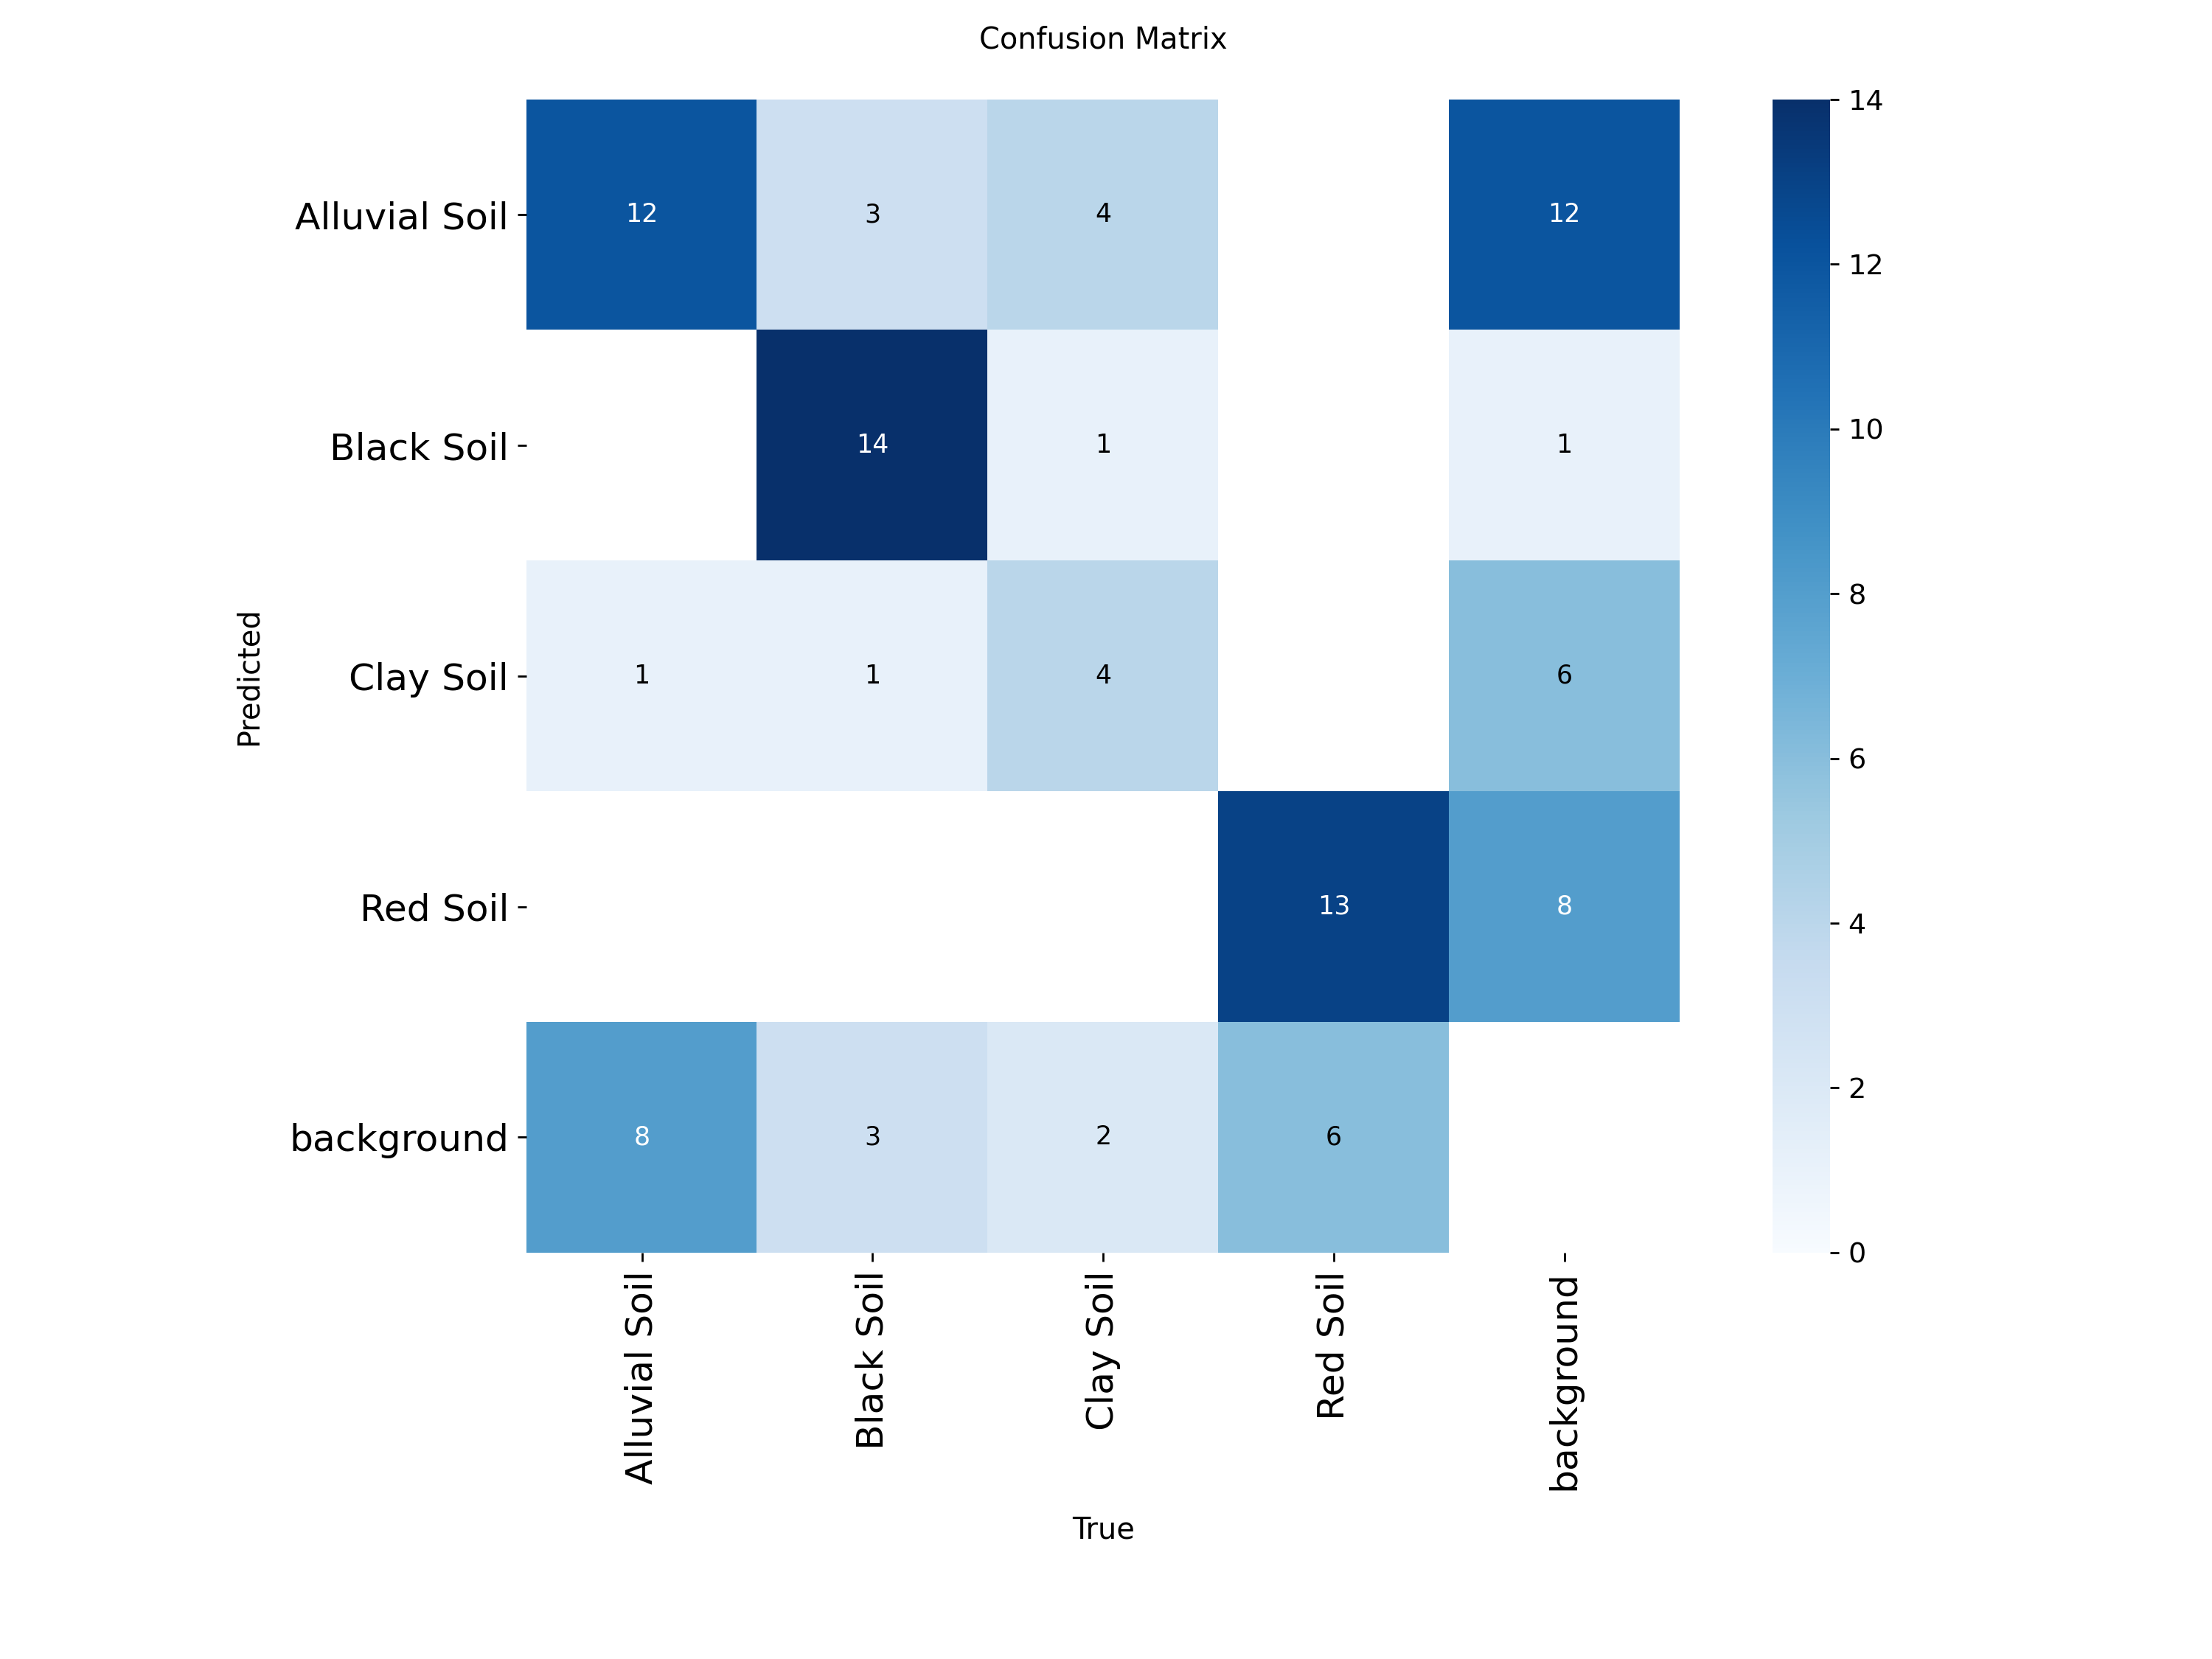

In [ ]:
resultData = '/content/runs/detect/train'
from IPython.display import Image, display

Image(filename=f'{resultData}/confusion_matrix.png')

In [ ]:
# The previous cell with the validation output provides precision and recall.
# We can extract those values to calculate the F1 score.

# The output from the validation cell (GdcfXz1aP9rF) shows:
# metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  metrics/mAP50-95(B)
#                0.635              0.646             0.57               0.315

precision = 0.635
recall = 0.646

# Calculate F1 Score
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1_score:.4f}")

Precision: 0.6350
Recall:    0.6460
F1 Score:  0.6405


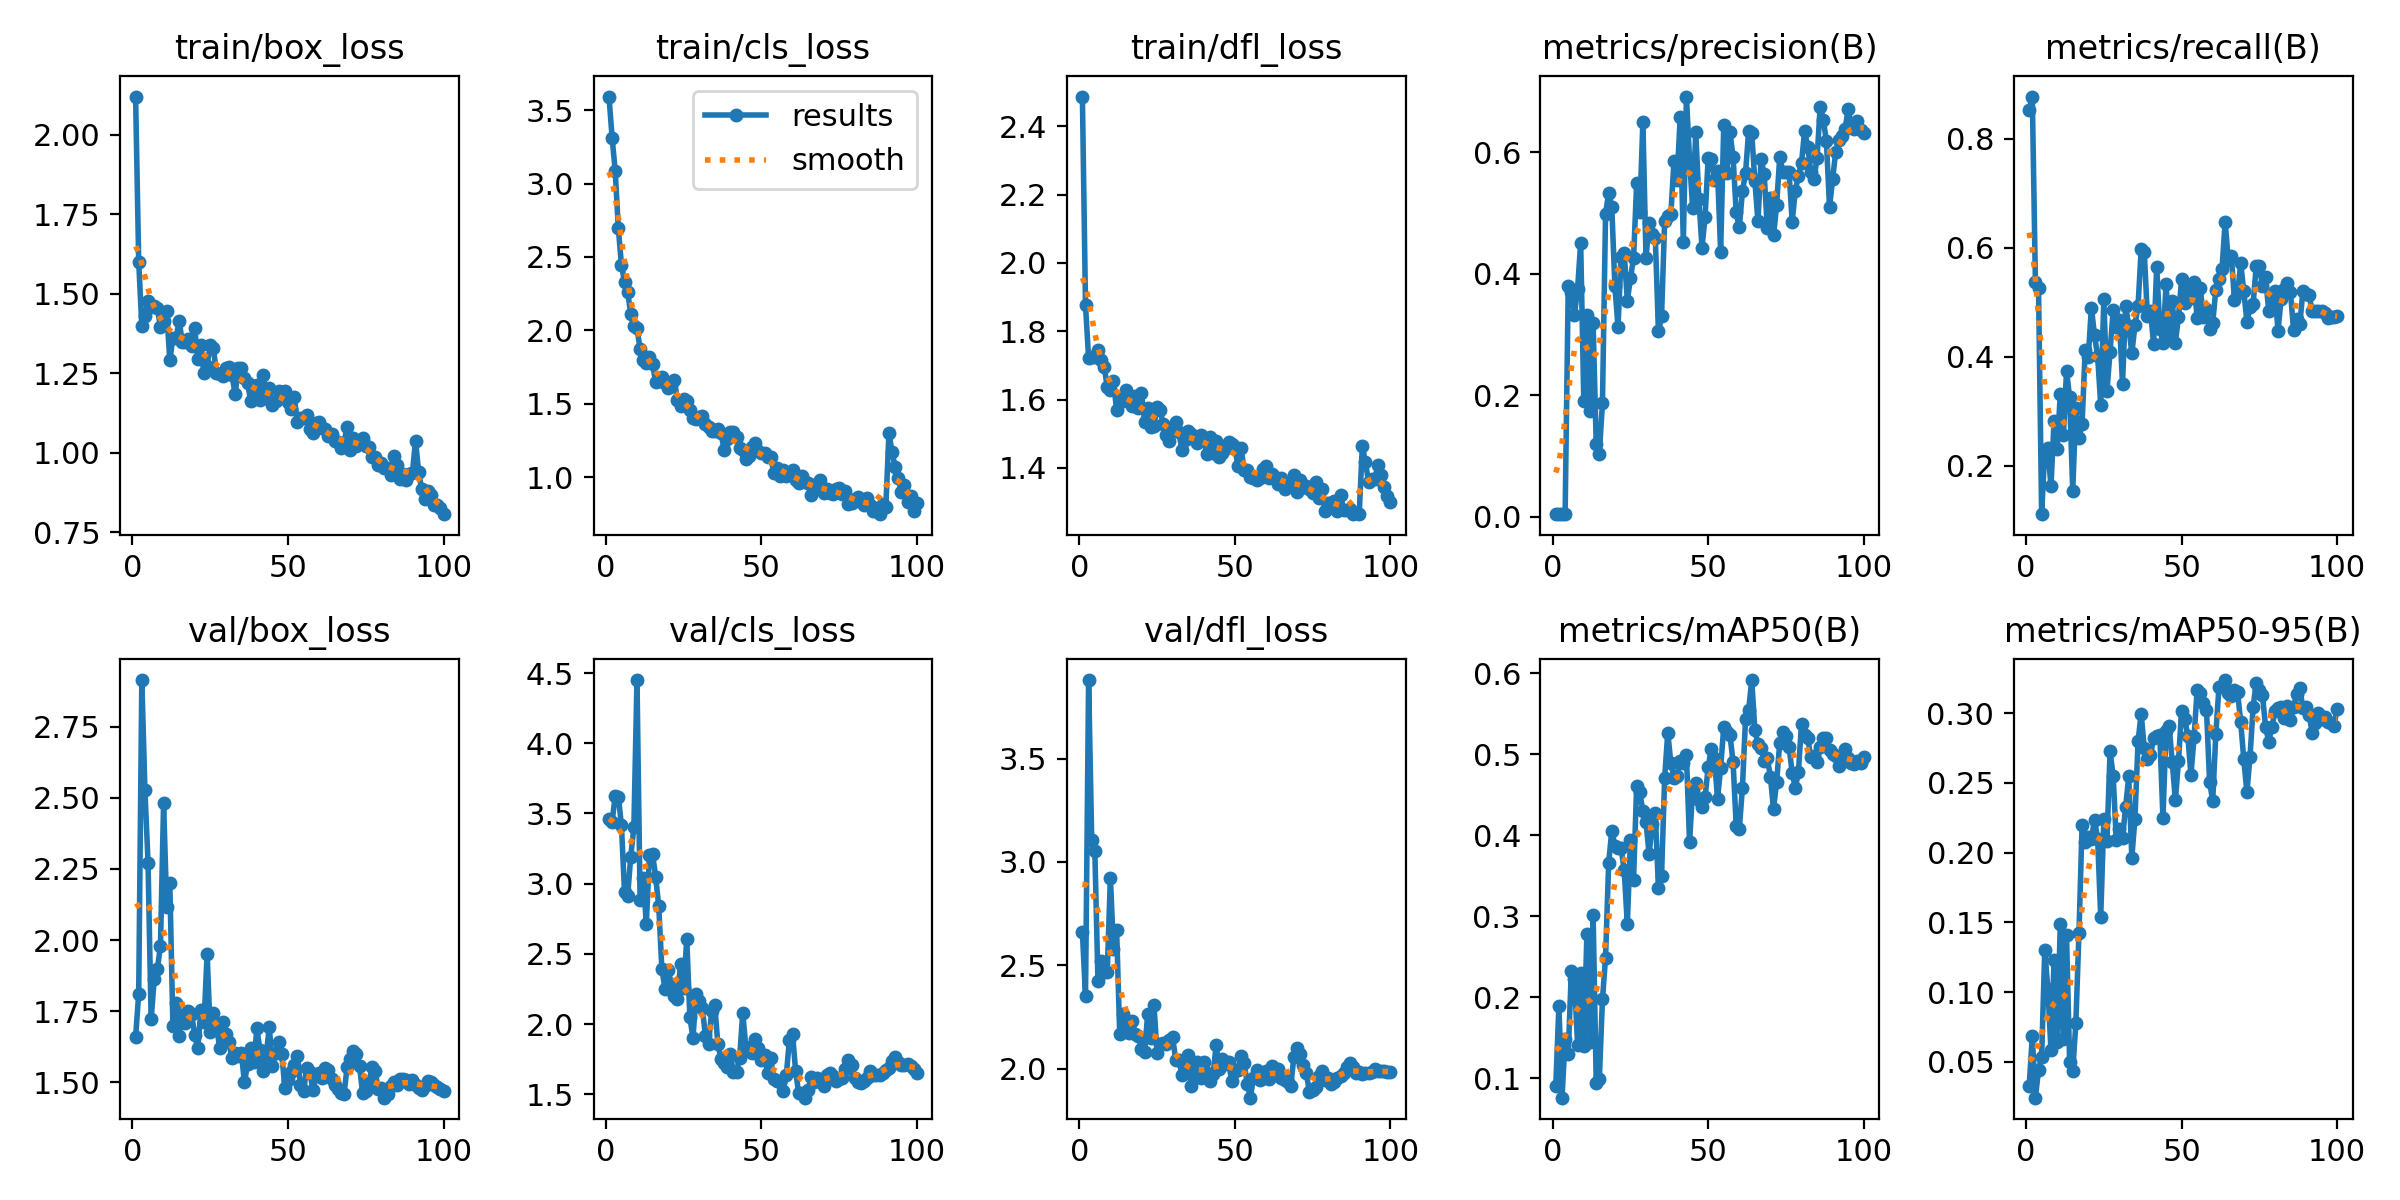

In [ ]:
from IPython.display import Image, display
Image(filename=f'{resultData}/results.png')

In [ ]:
import pandas as pd
df =pd.read_csv(f'{resultData}/results.csv') #df = dataframe
print (df.tail(1))

    epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  \
99    100  505.748         0.80654         0.82167         1.30005   

    metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
99               0.63137            0.47374           0.49714   

    metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
99              0.30328       1.46801       1.65482       1.98252  0.000025   

      lr/pg1    lr/pg2  
99  0.000025  0.000025  


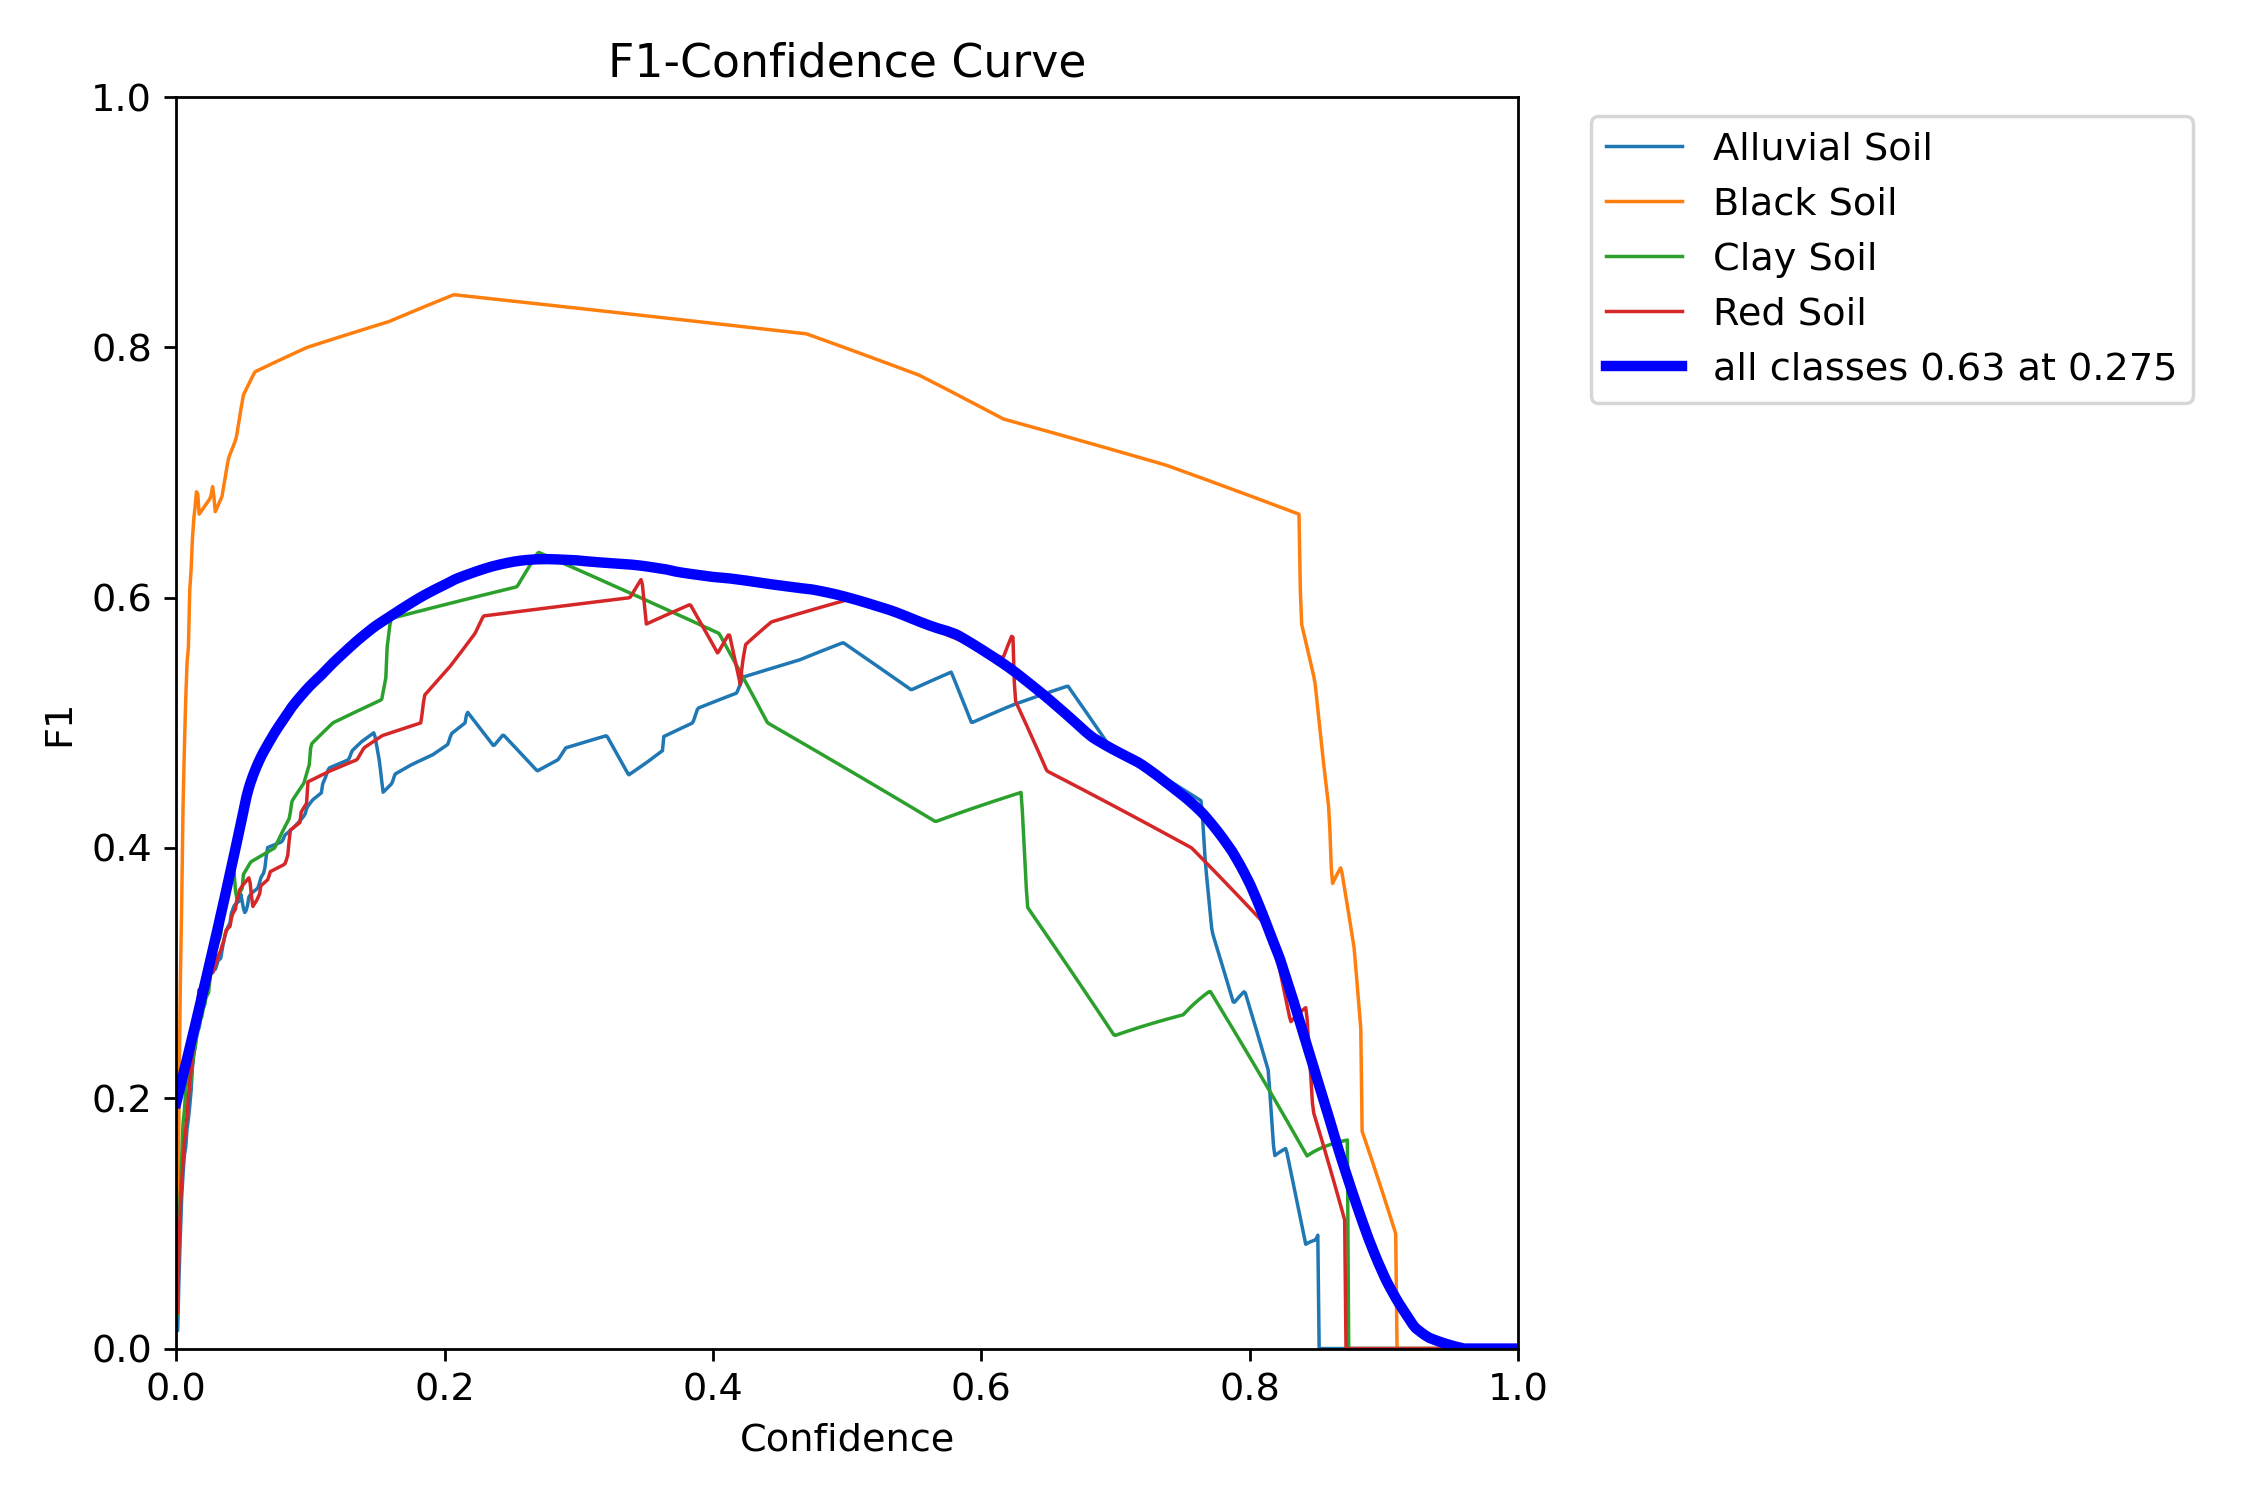

In [ ]:
from IPython.display import Image, display
Image(filename=f'{resultData}/BoxF1_curve.png')

In [ ]:
!yolo task=detect mode=val model={"/content/runs/detect/train3/weights/best.pt"} data={"/content/drive/MyDrive/Soil_detection.v2i.yolov11/data.yaml"}

Ultralytics 8.3.214 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 11.0±8.9 MB/s, size: 19.1 KB)
val: Scanning /content/drive/MyDrive/Soil_detection.v2i.yolov11/valid/labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 58/58 961.5Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.0it/s 2.0s
                   all         58         72      0.635      0.646       0.57      0.315
         Alluvial Soil         18         21      0.433      0.571      0.485      0.249
            Black Soil         17         21       0.94      0.749      0.806      0.456
             Clay Soil          9         11      0.635      0.632      0.474       0.22
              Red Soil         15         19      0.534      0.632      0.517      0.337
Speed: 2.5ms preproce

In [ ]:
!yolo task=detect mode=predict model={"/content/runs/detect/train3/weights/best.pt"} conf=.25 source="{ROOT_DIR}/test/images"

Ultralytics 8.3.214 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs

image 1/28 /content/drive/MyDrive/Soil_detection.v2i.yolov11/test/images/Black_38_jpg.rf.0abfbcb55b5a9b86110c5c64bfe473bf.jpg: 640x448 1 Black Soil, 46.3ms
image 2/28 /content/drive/MyDrive/Soil_detection.v2i.yolov11/test/images/Black_44_jpg.rf.f264c9be0f42ca8283699c92791d18ba.jpg: 640x640 (no detections), 9.4ms
image 3/28 /content/drive/MyDrive/Soil_detection.v2i.yolov11/test/images/Black_47_jpg.rf.bcbbfc307aad3c03ca7210e219387b8d.jpg: 256x640 1 Black Soil, 46.7ms
image 4/28 /content/drive/MyDrive/Soil_detection.v2i.yolov11/test/images/Clay_47_jpg.rf.0f5e60cd032d9d26beba5f1ccfb50b7b.jpg: 448x640 1 Clay Soil, 73.9ms
image 5/28 /content/drive/MyDrive/Soil_detection.v2i.yolov11/test/images/Copy-of-clay-soil-cropped_jpg.rf.e204f480fa0403c6a141de13f1fb58b5.jpg: 384x640 1 Clay Soil, 47.2ms
image 6/28 /content/drive/MyDrive/Soi

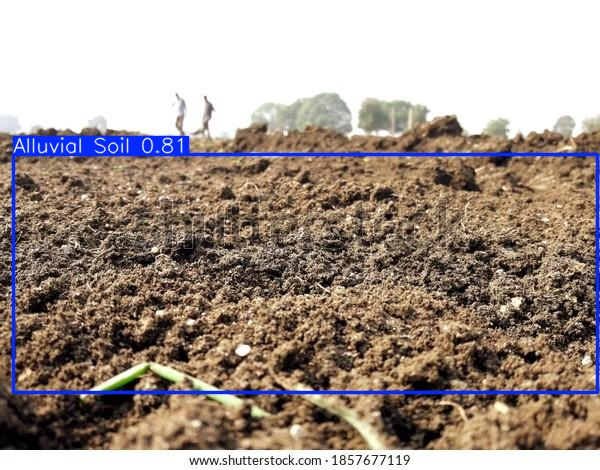

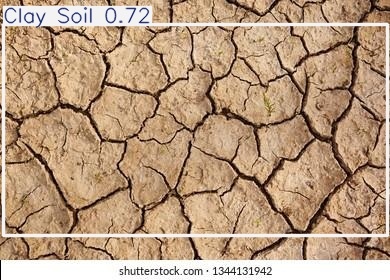

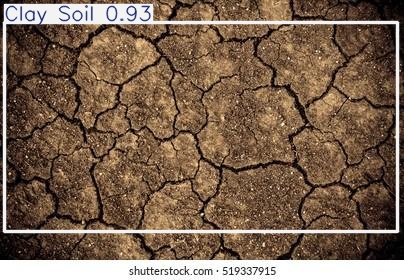

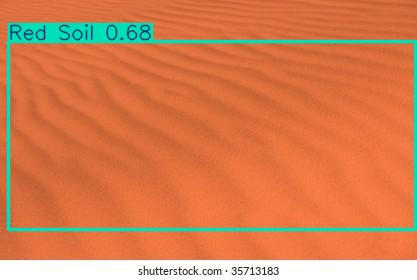

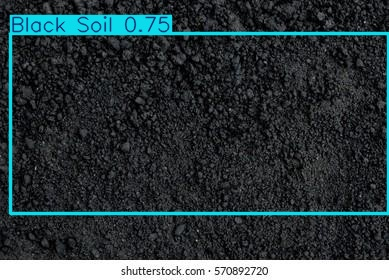

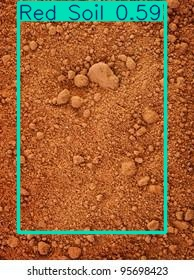

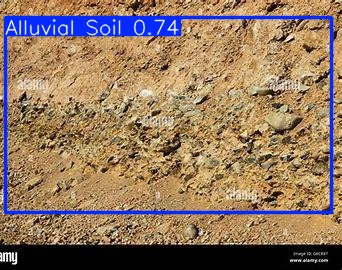

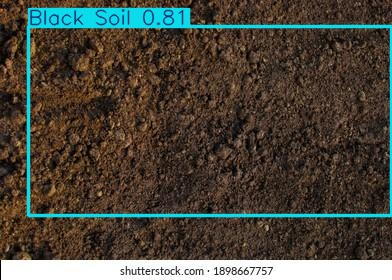

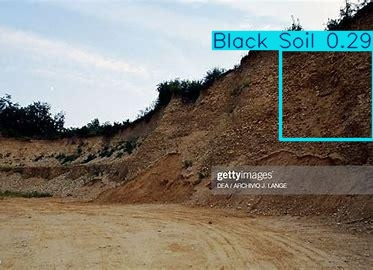

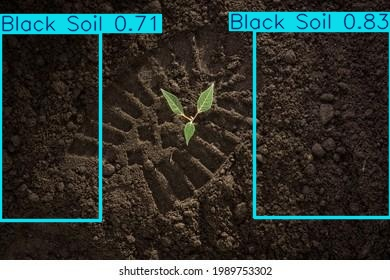

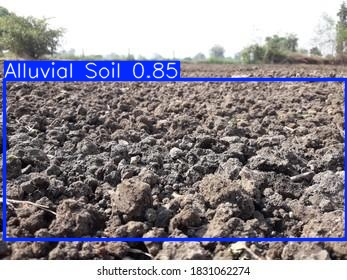

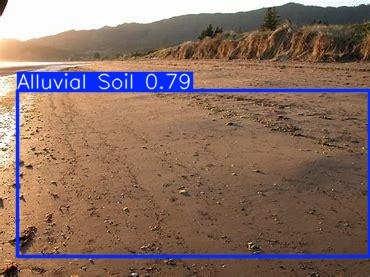

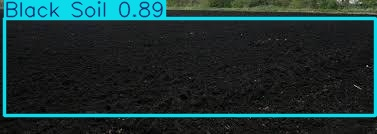

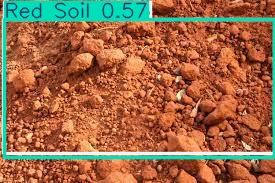

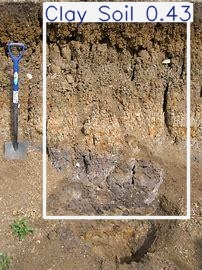

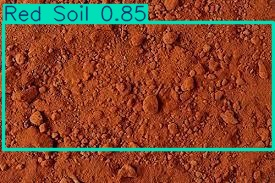

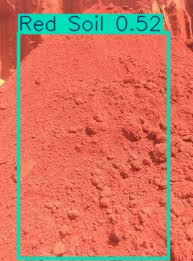

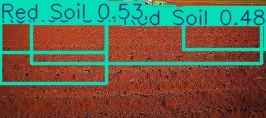

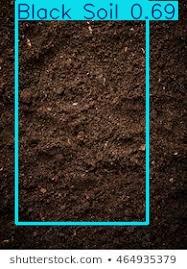

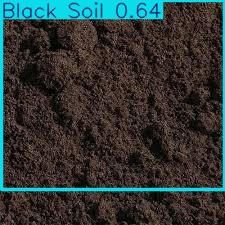

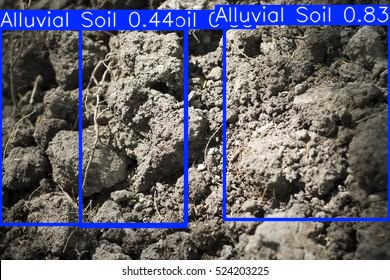

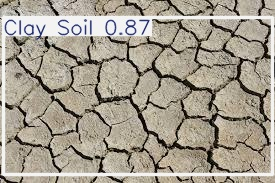

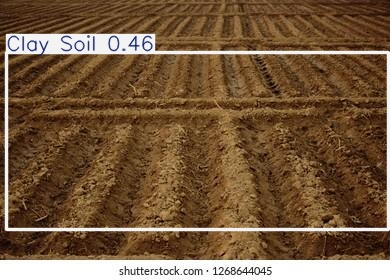

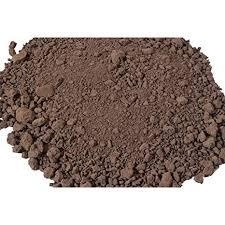

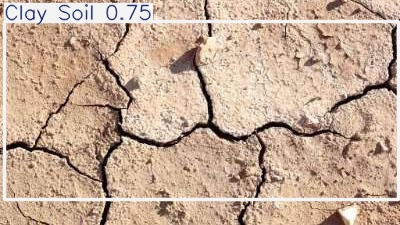

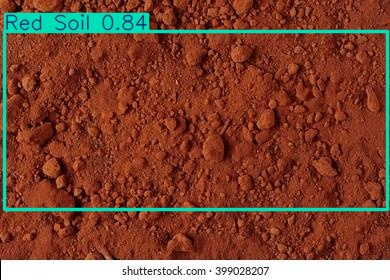

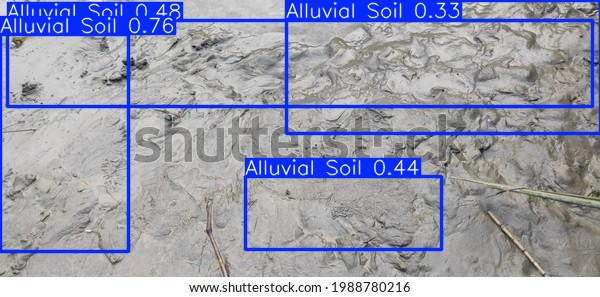

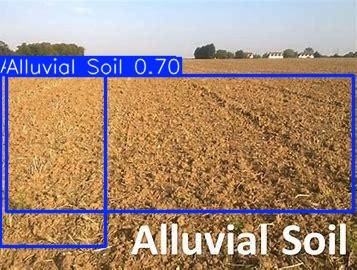

In [ ]:
import glob
from IPython.display import Image, display

for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg'):
  display(Image(filename=image_path, height=600))
  print('')